# Лінійна регресія на `log10(SalePrice)` з видаленням аномалій

Ноутбук продовжує `lab_1_learn_test`: ті самі `train/valid/test_data.csv`, ті самі власні
`OneHotEncoding`, `StandardScaler`, `CustomColumnTransformer` та лінійна регресія на градієнтному спуску (numpy).

**Що змінено відносно попереднього ноутбука**

1. **Аномалії видаляються лише з Train** (Valid/Test не чіпаємо, щоб оцінка якості лишалась чесною), у три кроки:
   IQR по `log10(SalePrice)` → z-score по неперервних ознаках → студентизовані залишки попередньої OLS-моделі.
2. Скейлер та OHE **фітяться вже на очищеному Train** (жодного витоку статистик з Valid/Test).
3. Ціль — `log10(SalePrice)`. Метрики рахуються і в лог-просторі, і в доларах (`10 ** pred`).
4. Вибір найкращого оптимізатора — **за Valid**, а не за Test.
5. Діагностика: графіки Residuals vs Fitted, Q-Q, Scale-Location; тести Шапіро–Вілка та Бройша–Пагана; VIF.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dataclasses import dataclass, field


DATA_DIR = "."            
TARGET = "SalePrice"
SEED = 42

REMOVE_OUTLIERS = True    
IQR_K = 1.5               
Z_THRESHOLD = 4.0         
RESID_THRESHOLD = 3.0     
ALPHA = 0.05              

np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.linestyle": ":"})

## 1. Власні препроцесори (без змін)

In [67]:
@dataclass
class OneHotEncoding:
    categories: dict = field(default_factory=dict)
    max_dim: int = 0

    def fit(self, x_col_numpy):
        unqs = np.unique(x_col_numpy)
        self.categories = {u: idx for idx, u in enumerate(unqs)}
        self.max_dim = len(unqs)
        return self

    def transform(self, x_col_num):
        len_samples = len(x_col_num)
        encoded = np.zeros(shape=(len_samples, self.max_dim))
        col_indices = np.array([self.categories.get(x, -1) for x in x_col_num])
        valid_mask = col_indices >= 0
        row_indices = np.arange(len_samples)
        encoded[row_indices[valid_mask], col_indices[valid_mask]] = 1
        return encoded

    def fit_transform(self, x_col_num):
        self.fit(x_col_num)
        return self.transform(x_col_num)


@dataclass
class StandardScaler:
    mean: float = 0.0
    std: float = 1.0

    def fit(self, x_num_col):
        self.mean = np.mean(x_num_col)
        self.std = np.std(x_num_col)
        if self.std == 0:
            self.std = 1e-8
        return self

    def transform(self, x_num_col):
        return (x_num_col - self.mean) / self.std

    def fit_transform(self, x_num_col):
        self.fit(x_num_col)
        return self.transform(x_num_col)


class CustomColumnTransformer:
    def __init__(self, transformers):
        self.transformers = transformers

    def fit(self, X, y=None):
        for name, transformer, cols in self.transformers:
            for col in cols:
                col_data = X[col].values
                if isinstance(transformer, StandardScaler):
                    setattr(self, f"{name}_{col}", StandardScaler().fit(col_data))
                elif isinstance(transformer, OneHotEncoding):
                    setattr(self, f"{name}_{col}", OneHotEncoding().fit(col_data))
        return self

    def transform(self, X):
        arrays = []
        for name, transformer, cols in self.transformers:
            for col in cols:
                res = getattr(self, f"{name}_{col}").transform(X[col].values)
                if res.ndim == 1:
                    res = res.reshape(-1, 1)
                arrays.append(res)
        return np.hstack(arrays)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

## 2. Дані

In [ ]:
train_data = pd.read_csv(f"{DATA_DIR}/train_data.csv")
valid_data = pd.read_csv(f"{DATA_DIR}/valid_data.csv")
test_data = pd.read_csv(f"{DATA_DIR}/test_data.csv")

X_train_raw, y_train_raw = train_data.drop(columns=TARGET), train_data[TARGET]
X_valid, y_valid_raw = valid_data.drop(columns=TARGET), valid_data[TARGET]
X_test, y_test_raw = test_data.drop(columns=TARGET), test_data[TARGET]

cat_cols = list(X_train_raw.select_dtypes(exclude="number").columns)
num_cols = list(X_train_raw.select_dtypes(include="number").columns)
cont_cols = [c for c in num_cols if X_train_raw[c].nunique() > 20]

print(f"Train/Valid/Test: {len(train_data)} / {len(valid_data)} / {len(test_data)}")
print(f"Числових ознак: {len(num_cols)}, категоріальних: {len(cat_cols)}, неперервних для z-score: {len(cont_cols)}")


def make_preprocessor():
    return CustomColumnTransformer([
        ("num_scaler", StandardScaler(), num_cols),
        ("cat_ohe", OneHotEncoding(), cat_cols),
    ])

Train/Valid/Test: 1873 / 470 / 587
Числових ознак: 8, категоріальних: 39, неперервних для z-score: 5


## 3. Видалення аномалій (лише Train)

| Крок | Що ловить | Правило |
|---|---|---|
| 1. IQR по `log10(SalePrice)` | екстремально дешеві/дорогі об'єкти | поза `[Q1 − k·IQR, Q3 + k·IQR]` |
| 2. z-score по неперервних ознаках | аномальні площі/розміри (важелі) | `abs(z) > Z_THRESHOLD` хоча б в одній ознаці |
| 3. Студентизовані залишки OLS | об'єкти, ціна яких не пояснюється ознаками (напр. велика площа при низькій ціні) | `abs(t) > RESID_THRESHOLD`; залишки скориговано на важіль `h_ii` |

Кроки застосовуються послідовно: кожен наступний бачить уже відфільтровані дані.

                                         Крок  Видалено
                   1. IQR по log10(SalePrice)        37
2. z-score (|z| > 4.0) по неперервних ознаках        17
                  3. |студент. залишок| > 3.0        27

Всього видалено: 81 із 1873 (4.32%); залишилось 1792


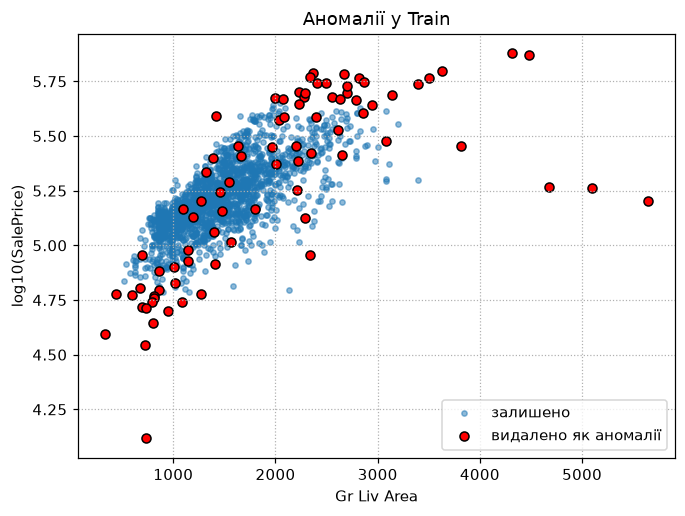

In [ ]:
def iqr_outlier_mask(values, k):
    """True = аномалія."""
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return (values < q1 - k * iqr) | (values > q3 + k * iqr)


def zscore_outlier_mask(df, cols, thr):
    if not cols:
        return np.zeros(len(df), dtype=bool)
    z = (df[cols] - df[cols].mean()) / df[cols].std(ddof=0).replace(0, np.nan)
    return (z.abs() > thr).any(axis=1).values


def studentized_residuals(X, y):
    Z = np.column_stack([np.ones(len(X)), X])
    U, s, _ = np.linalg.svd(Z, full_matrices=False)
    rank = int((s > s.max() * max(Z.shape) * np.finfo(float).eps).sum())
    U_r = U[:, :rank]
    y = y.reshape(-1)
    e = y - U_r @ (U_r.T @ y)
    h = (U_r ** 2).sum(axis=1)
    s2 = (e @ e) / (len(y) - rank)
    t = e / np.sqrt(s2 * np.clip(1 - h, 1e-8, None))
    return t, h


if REMOVE_OUTLIERS:
    n0 = len(train_data)
    keep = np.ones(n0, dtype=bool)
    log_y = np.log10(y_train_raw.values)
    report = []

    out1 = iqr_outlier_mask(log_y, IQR_K)
    report.append(("1. IQR по log10(SalePrice)", int(out1.sum())))
    keep &= ~out1

    out2 = np.zeros(n0, dtype=bool)
    out2[keep] = zscore_outlier_mask(X_train_raw[keep], cont_cols, Z_THRESHOLD)
    report.append((f"2. z-score (|z| > {Z_THRESHOLD}) по неперервних ознаках", int(out2.sum())))
    keep &= ~out2

    prep_tmp = make_preprocessor().fit(X_train_raw[keep])
    t, h = studentized_residuals(prep_tmp.transform(X_train_raw[keep]), log_y[keep])
    out3 = np.zeros(n0, dtype=bool)
    out3[np.where(keep)[0][np.abs(t) > RESID_THRESHOLD]] = True
    report.append((f"3. |студент. залишок| > {RESID_THRESHOLD}", int(out3.sum())))
    keep &= ~out3

    removed = ~keep
    print(pd.DataFrame(report, columns=["Крок", "Видалено"]).to_string(index=False))
    print(f"\nВсього видалено: {removed.sum()} із {n0} ({removed.mean():.2%}); залишилось {keep.sum()}")

    if cont_cols:
        corr_with_y = {c: abs(np.corrcoef(X_train_raw[c], log_y)[0, 1]) for c in cont_cols}
        feat = max(corr_with_y, key=corr_with_y.get)
        plt.figure(figsize=(7, 5))
        plt.scatter(X_train_raw.loc[keep, feat], log_y[keep], s=12, alpha=0.5, label="залишено")
        plt.scatter(X_train_raw.loc[removed, feat], log_y[removed], s=35, c="red",
                    edgecolors="k", label="видалено як аномалії")
        plt.xlabel(feat)
        plt.ylabel("log10(SalePrice)")
        plt.title("Аномалії у Train")
        plt.legend()
        plt.show()
else:
    keep = np.ones(len(train_data), dtype=bool)
    print("REMOVE_OUTLIERS = False: навчання на повному Train")

X_train = X_train_raw[keep].reset_index(drop=True)
y_train_raw = y_train_raw[keep].reset_index(drop=True)

## 4. Кодування, масштабування та лог-ціль

Препроцесор фітиться **на очищеному Train**. Ціль перетворюється як `log10(SalePrice)`.

In [70]:
preprocessor = make_preprocessor()
X_train_p = preprocessor.fit_transform(X_train)
X_valid_p = preprocessor.transform(X_valid)
X_test_p = preprocessor.transform(X_test)

y_train_usd = y_train_raw.values.reshape(-1, 1).astype(float)
y_valid_usd = y_valid_raw.values.reshape(-1, 1).astype(float)
y_test_usd = y_test_raw.values.reshape(-1, 1).astype(float)

y_train_log = np.log10(y_train_usd)
y_valid_log = np.log10(y_valid_usd)
y_test_log = np.log10(y_test_usd)

print("X_train:", X_train_p.shape, "| X_valid:", X_valid_p.shape, "| X_test:", X_test_p.shape)

X_train: (1792, 262) | X_valid: (470, 262) | X_test: (587, 262)


## 5. Модель та метрики

Та сама лінійна регресія з градієнтним спуском, що й раніше (`dw = Xᵀ·err / B`). Відмінності:

* батчі **перемішуються щоразу на новій епосі** і останній неповний батч не відкидається;
* зсув `b` ініціалізується середнім `log10(y)` (ціль ≈ 5, стартувати з 0 марно довго);
* Early Stopping за Valid MSE і **завжди** відновлюються найкращі ваги;
* додано OLS через `lstsq` як **еталон**: показує, наскільки GD зійшовся до оптимуму.

In [ ]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)


class LinearRegressionGD:
    def __init__(self, seed=SEED):
        self.seed = seed
        self.w, self.b = None, 0.0
        self.history = {}
        self.best_epoch = None
        self.diverged = False

    def predict(self, X):
        return X @ self.w + self.b

    def fit(self, X, y, X_valid, y_valid, batch_size, alpha, epochs, patience=10, min_delta=1e-7):
        rng = np.random.default_rng(self.seed)
        m, d = X.shape
        self.w = rng.normal(0, 0.01, size=(d, 1))
        self.b = float(y.mean())
        self.history = {k: [] for k in ("train_loss", "valid_loss", "train_r2", "valid_r2")}
        best_val, best_w, best_b, wait = np.inf, self.w.copy(), self.b, 0

        for epoch in range(epochs):
            perm = rng.permutation(m)
            for start in range(0, m, batch_size):
                idx = perm[start:start + batch_size]
                err = X[idx] @ self.w + self.b - y[idx]
                self.w -= alpha * (X[idx].T @ err) / len(idx)
                self.b -= alpha * float(err.mean())

            p_tr, p_va = self.predict(X), self.predict(X_valid)
            tr_loss, va_loss = mse(y, p_tr), mse(y_valid, p_va)
            if not np.isfinite(tr_loss):
                self.diverged = True
                warnings.warn(f"GD розійшовся на епосі {epoch + 1} (alpha={alpha}); зменшіть alpha.")
                break
            self.history["train_loss"].append(tr_loss)
            self.history["valid_loss"].append(va_loss)
            self.history["train_r2"].append(r2(y, p_tr))
            self.history["valid_r2"].append(r2(y_valid, p_va))

            if va_loss < best_val - min_delta:
                best_val, best_w, best_b, wait = va_loss, self.w.copy(), self.b, 0
                self.best_epoch = epoch + 1
            else:
                wait += 1
                if wait >= patience:
                    break

        self.w, self.b = best_w, best_b
        return self


class OLSReference:
    def fit(self, X, y):
        Z = np.column_stack([np.ones(len(X)), X])
        beta, *_ = np.linalg.lstsq(Z, y, rcond=None)
        self.b, self.w = float(beta[0, 0]), beta[1:]
        return self

    def predict(self, X):
        return X @ self.w + self.b


def dollar_metrics(y_log_true, y_log_pred):
    y_t, y_p = 10 ** y_log_true, 10 ** y_log_pred
    return {
        "R2": r2(y_t, y_p),
        "RMSE": float(np.sqrt(mse(y_t, y_p))),
        "MAE": float(np.mean(np.abs(y_t - y_p))),
        "MAPE, %": float(np.mean(np.abs((y_t - y_p) / y_t)) * 100),
    }

## 6. Навчання трьох варіантів GD на `log10(SalePrice)`

In [72]:
m_train = X_train_p.shape[0]

configs = [
    # назва,                    batch_size, alpha,  epochs
    ("Batch GD (B = m)",        m_train,    0.05,   350),
    ("Mini-batch GD (B = 32)",  32,         0.01,   100),
    ("SGD (B = 1)",             1,          0.002,  25),
]

models = {}
for name, bs, lr, eps in configs:
    models[name] = LinearRegressionGD().fit(
        X_train_p, y_train_log, X_valid_p, y_valid_log,
        batch_size=bs, alpha=lr, epochs=eps, patience=10,
    )
    h = models[name].history
    print(f"{name:26s} епох: {len(h['train_loss']):3d} | найкраща епоха: {models[name].best_epoch} "
          f"| Valid MSE(log10) = {min(h['valid_loss']):.5f}")

ols = OLSReference().fit(X_train_p, y_train_log)
all_models = {**models, "OLS (lstsq, еталон)": ols}

Batch GD (B = m)           епох: 350 | найкраща епоха: 350 | Valid MSE(log10) = 0.00419
Mini-batch GD (B = 32)     епох:  95 | найкраща епоха: 85 | Valid MSE(log10) = 0.00406
SGD (B = 1)                епох:  25 | найкраща епоха: 19 | Valid MSE(log10) = 0.00403


## 7. Метрики

**У лог-просторі** (`log10(SalePrice)`) — те, що реально оптимізується, та **в доларах** (`10 ** pred`).
Зворотне перетворення `10 ** pred` дає радше медіану, ніж середнє умовного розподілу, тому долар-метрики можуть
бути трохи песимістичнішими за лог-метрики.

In [ ]:
splits = {
    "Train": (X_train_p, y_train_log),
    "Valid": (X_valid_p, y_valid_log),
    "Test":  (X_test_p,  y_test_log),
}

rows_log, rows_usd = [], []
for name, mdl in all_models.items():
    row_l, row_d = {"Модель": name}, {"Модель": name}
    for sp, (Xs, ys) in splits.items():
        pred = mdl.predict(Xs)
        row_l[f"{sp} R²"] = r2(ys, pred)
        row_d[f"{sp} R²"] = dollar_metrics(ys, pred)["R2"]
        if sp == "Test":
            row_l["Test RMSE (log10)"] = float(np.sqrt(mse(ys, pred)))
            dm = dollar_metrics(ys, pred)
            row_d.update({"Test RMSE ($)": dm["RMSE"], "Test MAE ($)": dm["MAE"], "Test MAPE, %": dm["MAPE, %"]})
    rows_log.append(row_l)
    rows_usd.append(row_d)

metrics_log = pd.DataFrame(rows_log).set_index("Модель")
metrics_usd = pd.DataFrame(rows_usd).set_index("Модель")

print("Метрики в лог-просторі (log10 SalePrice)")
display(metrics_log.round(4))
print("Метрики в доларах (після 10 ** pred)")
display(metrics_usd.round(4))

best_name = min(models, key=lambda n: min(models[n].history["valid_loss"]))
best_model = models[best_name]
print(f"Найкращий за Valid MSE: {best_name}")

Метрики в лог-просторі (log10 SalePrice)


,Train R²,Valid R²,Test R²,Test RMSE (log10)
Модель,,,,
Batch GD (B = m),0.9307,0.8765,0.8977,0.0548
Mini-batch GD (B = 32),0.9395,0.8802,0.901,0.0539
SGD (B = 1),0.9409,0.8813,0.9006,0.0541
"OLS (lstsq, еталон)",0.9508,0.8696,0.8921,0.0563


Метрики в доларах (після 10 ** pred)


,Train R²,Valid R²,Test R²,Test RMSE ($),Test MAE ($),"Test MAPE, %"
Модель,,,,,,
Batch GD (B = m),0.9351,0.9205,0.9226,2.106e+04,1.446e+04,9.081
Mini-batch GD (B = 32),0.9422,0.9259,0.9246,2.078e+04,1.435e+04,8.974
SGD (B = 1),0.943,0.927,0.9222,2.111e+04,1.464e+04,9.091
"OLS (lstsq, еталон)",0.9512,0.9227,0.9019,2.37e+04,1.538e+04,9.312


Найкращий за Valid MSE: SGD (B = 1)


## 8. Графіки навчання

Зверху — MSE (log10) на Train/Valid, знизу — R². Вертикальна лінія — епоха з найкращими вагами (Early Stopping).
Осі епох різні: у Batch GD одна епоха = один крок, у SGD — `m` кроків.

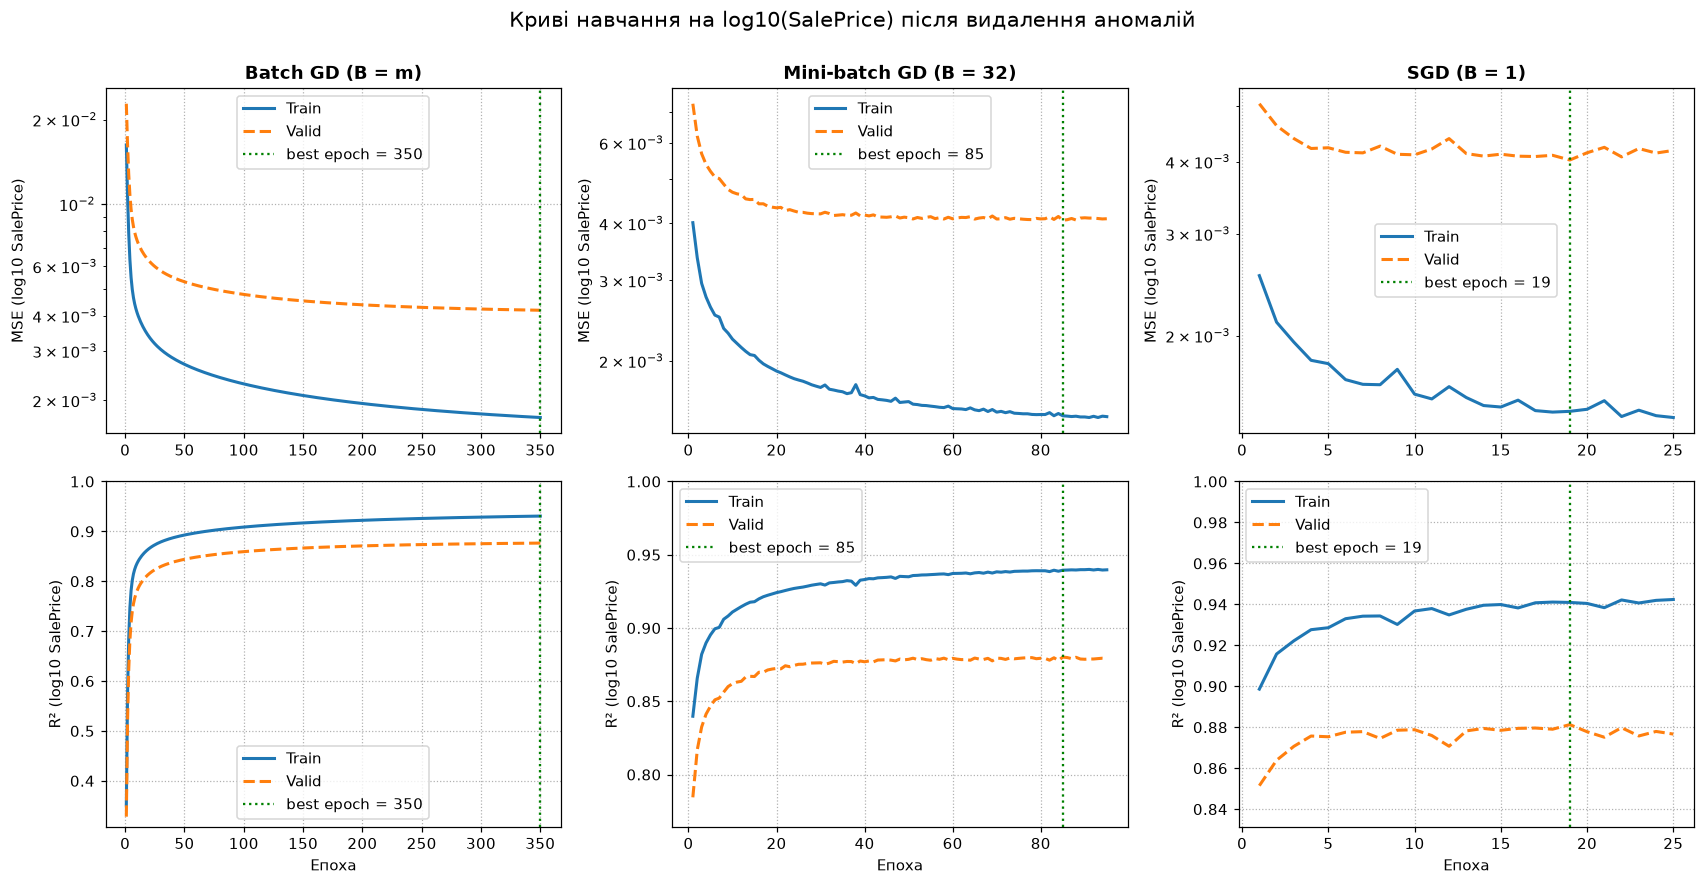

In [74]:
fig, axs = plt.subplots(2, len(models), figsize=(5.2 * len(models), 8), squeeze=False)

for j, (name, mdl) in enumerate(models.items()):
    h = mdl.history
    ep = np.arange(1, len(h["train_loss"]) + 1)

    axs[0, j].plot(ep, h["train_loss"], label="Train", lw=2)
    axs[0, j].plot(ep, h["valid_loss"], "--", label="Valid", lw=2)
    axs[0, j].set_yscale("log")
    axs[0, j].set_title(name, fontweight="bold")
    axs[0, j].set_ylabel("MSE (log10 SalePrice)")

    axs[1, j].plot(ep, h["train_r2"], label="Train", lw=2)
    axs[1, j].plot(ep, h["valid_r2"], "--", label="Valid", lw=2)
    axs[1, j].set_ylim(max(-0.1, min(h["train_r2"] + h["valid_r2"]) - 0.02), 1.0)
    axs[1, j].set_xlabel("Епоха")
    axs[1, j].set_ylabel("R² (log10 SalePrice)")

    for row in (0, 1):
        if mdl.best_epoch:
            axs[row, j].axvline(mdl.best_epoch, color="green", ls=":", label=f"best epoch = {mdl.best_epoch}")
        axs[row, j].legend()

fig.suptitle("Криві навчання на log10(SalePrice) після видалення аномалій", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 9. Діагностика залишків

Залишки `e = log10(y) − log10(ŷ)`. Для перевірки припущень OLS важлива вибірка, на якій модель **навчалась** (Train),
але для контролю дивимось і на Test. Червона лінія на графіках 1 та 3 — середнє по квантильних бінах (згладжений тренд):
для лінійності та гомоскедастичності вона має бути горизонтальною.

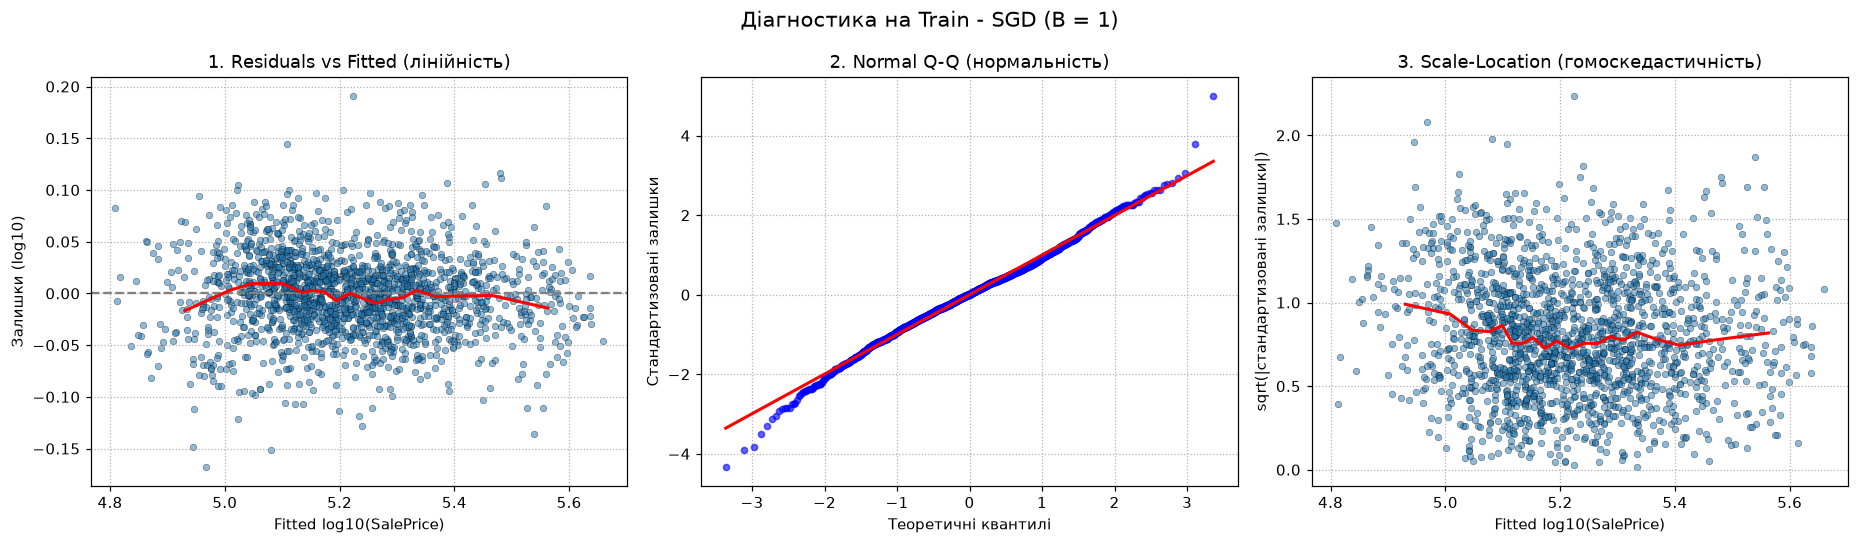

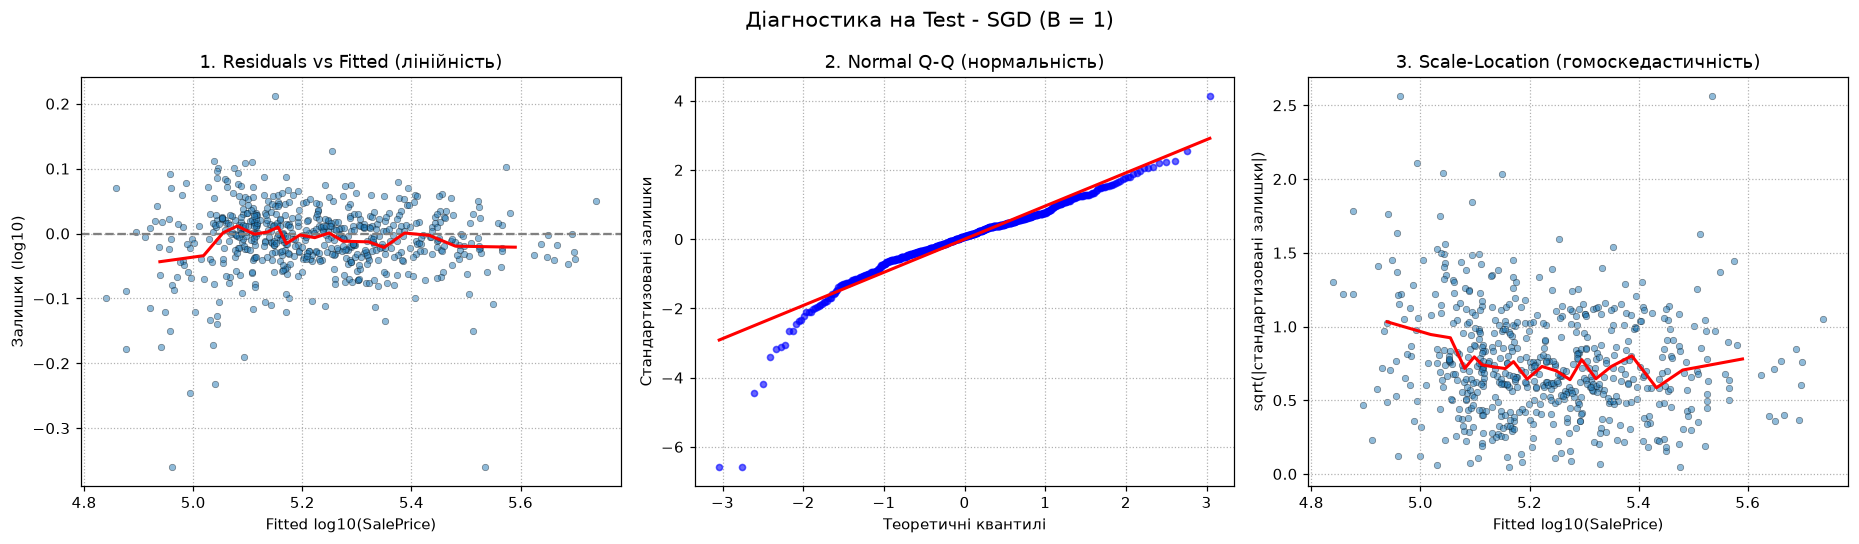

In [75]:
def binned_trend(x, y, n_bins=20):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    idx = np.clip(np.digitize(x, edges[1:-1]), 0, n_bins - 1)
    xs = np.array([x[idx == b].mean() for b in range(n_bins) if np.any(idx == b)])
    ys = np.array([y[idx == b].mean() for b in range(n_bins) if np.any(idx == b)])
    return xs, ys


def residual_diagnostics(y_log_true, y_log_pred, title):
    fitted = y_log_pred.reshape(-1)
    resid = y_log_true.reshape(-1) - fitted
    resid_std = (resid - resid.mean()) / resid.std()
    sqrt_abs = np.sqrt(np.abs(resid_std))

    fig, axs = plt.subplots(1, 3, figsize=(17, 5))

    # 1. Residuals vs Fitted
    axs[0].scatter(fitted, resid, alpha=0.5, edgecolors="k", linewidth=0.4, s=18)
    axs[0].axhline(0, color="gray", ls="--")
    axs[0].plot(*binned_trend(fitted, resid), color="red", lw=2)
    axs[0].set_title("1. Residuals vs Fitted (лінійність)")
    axs[0].set_xlabel("Fitted log10(SalePrice)")
    axs[0].set_ylabel("Залишки (log10)")

    # 2. Normal Q-Q
    stats.probplot(resid_std, dist="norm", plot=axs[1])
    axs[1].get_lines()[0].set(markersize=4, alpha=0.6)
    axs[1].get_lines()[1].set(color="red", lw=2)
    axs[1].set_title("2. Normal Q-Q (нормальність)")
    axs[1].set_xlabel("Теоретичні квантилі")
    axs[1].set_ylabel("Стандартизовані залишки")

    # 3. Scale-Location
    axs[2].scatter(fitted, sqrt_abs, alpha=0.5, edgecolors="k", linewidth=0.4, s=18)
    axs[2].plot(*binned_trend(fitted, sqrt_abs), color="red", lw=2)
    axs[2].set_title("3. Scale-Location (гомоскедастичність)")
    axs[2].set_xlabel("Fitted log10(SalePrice)")
    axs[2].set_ylabel("sqrt(|стандартизовані залишки|)")

    fig.suptitle(f"{title} - {best_name}", fontsize=14)
    plt.tight_layout()
    plt.show()
    return resid


pred_train_log = best_model.predict(X_train_p)
pred_test_log = best_model.predict(X_test_p)

resid_train = residual_diagnostics(y_train_log, pred_train_log, "Діагностика на Train")
resid_test = residual_diagnostics(y_test_log, pred_test_log, "Діагностика на Test")

## 10. Формальні тести

* **Шапіро–Вілка** — `H0`: залишки нормальні.
* **Бройша–Пагана** (варіант Кенкера, `LM = n·R²` допоміжної регресії `e²` на регресори) — `H0`: гомоскедастичність.
  Робимо два варіанти: **на всіх регресорах** (класичний) та **лише на fitted** (як було в попередньому ноутбуці).
  Ступені свободи класичного варіанту = `rank(Z) − 1`, бо повний OHE містить колінеарні стовпці.
* **VIF** — для числових ознак очищеного Train: `VIF_j = [R⁻¹]_jj`, де `R` — кореляційна матриця.
  Для OHE VIF не рахуємо: повний набір дамі-стовпців принципово сумарно колінеарний з інтерсептом.

Інтерпретація: `p < ALPHA` → `H0` відхиляється. Для великих вибірок Шапіро майже завжди «ловить» дрібні
відхилення, тому дивіться разом із Q-Q графіком.

In [ ]:
def breusch_pagan(resid, Z_reg):
    """Koenker-версія BP: LM = n * R^2 регресії e^2 на [1, Z_reg]."""
    resid = resid.reshape(-1)
    Z = np.column_stack([np.ones(len(resid)), Z_reg])
    e2 = resid ** 2
    beta, *_ = np.linalg.lstsq(Z, e2, rcond=None)
    ss_res = np.sum((e2 - Z @ beta) ** 2)
    ss_tot = np.sum((e2 - e2.mean()) ** 2)
    r2_aux = 1 - ss_res / ss_tot
    df = np.linalg.matrix_rank(Z) - 1
    lm = len(resid) * r2_aux
    return float(lm), float(stats.chi2.sf(lm, df)), int(df)


def run_tests(resid, X_p, fitted, label):
    rows = []
    sample = resid if len(resid) <= 5000 else np.random.default_rng(SEED).choice(resid, 5000, replace=False)
    w, p = stats.shapiro(sample)
    rows.append({"Вибірка": label, "Тест": "Шапіро–Вілка", "Статистика": w, "df": "-", "p-value": p,
                 "Висновок": "H0 не відхилено (нормальність)" if p > ALPHA else "H0 відхилено (не нормальні)"})
    lm, p, df = breusch_pagan(resid, X_p)
    rows.append({"Вибірка": label, "Тест": "Бройш–Паган (усі регресори)", "Статистика": lm, "df": df, "p-value": p,
                 "Висновок": "H0 не відхилено (гомоскедастичність)" if p > ALPHA else "H0 відхилено (гетероскедастичність)"})
    lm, p, df = breusch_pagan(resid, fitted.reshape(-1, 1))
    rows.append({"Вибірка": label, "Тест": "Бройш–Паган (за fitted)", "Статистика": lm, "df": df, "p-value": p,
                 "Висновок": "H0 не відхилено (гомоскедастичність)" if p > ALPHA else "H0 відхилено (гетероскедастичність)"})
    return rows


tests_df = pd.DataFrame(
    run_tests(resid_train, X_train_p, pred_train_log, "Train")
    + run_tests(resid_test, X_test_p, pred_test_log, "Test")
)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
display(tests_df)

,Вибірка,Тест,Статистика,df,p-value,Висновок
0,Train,Шапіро–Вілка,0.9932,-,2.612e-07,H0 відхилено (не нормальні)
1,Train,Бройш–Паган (усі регресори),693.5,218,5.879e-51,H0 відхилено (гетероскедастичність)
2,Train,Бройш–Паган (за fitted),12.2,1,0.0004779,H0 відхилено (гетероскедастичність)
3,Test,Шапіро–Вілка,0.9141,-,9.938e-18,H0 відхилено (не нормальні)
4,Test,Бройш–Паган (усі регресори),408,191,7.98e-18,H0 відхилено (гетероскедастичність)
5,Test,Бройш–Паган (за fitted),6.625,1,0.01006,H0 відхилено (гетероскедастичність)


,Feature,VIF,Стан
0,Overall Qual,2.584,прийнятно (<5)
1,year_build_sold,2.331,прийнятно (<5)
2,Gr Liv Area,2.168,прийнятно (<5)
3,Full Bath,2.085,прийнятно (<5)
4,Garage Cars,1.894,прийнятно (<5)
5,year_remod_sold,1.776,прийнятно (<5)
6,Total Bsmt SF,1.464,прийнятно (<5)
7,Mas Vnr Area,1.288,прийнятно (<5)


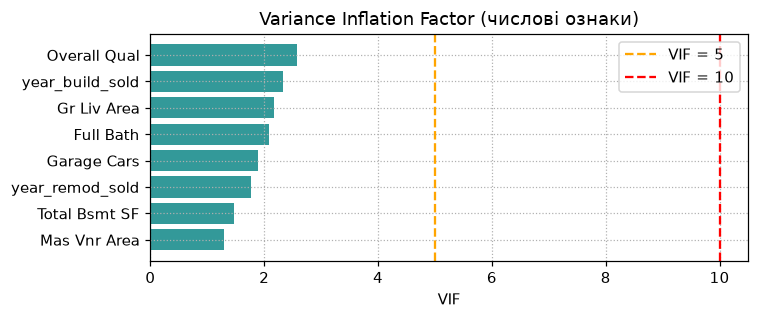

In [ ]:
X_num = X_train[num_cols].astype(float)
X_num = X_num.loc[:, X_num.std(ddof=0) > 0]          
corr = np.corrcoef(X_num.values, rowvar=False)

try:
    vif = np.diag(np.linalg.inv(corr))
except np.linalg.LinAlgError:
    vif = np.diag(np.linalg.pinv(corr))
    print("Кореляційна матриця виродена: використано псевдообернену (VIF наближені).")

vif_df = (pd.DataFrame({"Feature": X_num.columns, "VIF": vif})
          .sort_values("VIF", ascending=False).reset_index(drop=True))
vif_df["Стан"] = np.where(vif_df["VIF"] > 10, "серйозна колінеарність (>10)",
                  np.where(vif_df["VIF"] > 5, "помірна (5-10)", "прийнятно (<5)"))
display(vif_df)

plt.figure(figsize=(7, max(3, 0.32 * len(vif_df))))
plt.barh(vif_df["Feature"][::-1], vif_df["VIF"][::-1], color="teal", alpha=0.8)
plt.axvline(5, color="orange", ls="--", label="VIF = 5")
plt.axvline(10, color="red", ls="--", label="VIF = 10")
plt.xlabel("VIF")
plt.title("Variance Inflation Factor (числові ознаки)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
t = tests_df.set_index(["Вибірка", "Тест"])
print("=" * 70)
print("ПІДСУМОК ПЕРЕДУМОВ OLS (модель:", best_name + ")")
print("=" * 70)
for sample in ("Train", "Test"):
    p_sw = t.loc[(sample, "Шапіро–Вілка"), "p-value"]
    p_bp = t.loc[(sample, "Бройш–Паган (усі регресори)"), "p-value"]
    print(f"[{sample}] нормальність:       {'ОК' if p_sw > ALPHA else 'порушено'} (p = {p_sw:.3g})")
    print(f"[{sample}] гомоскедастичність: {'ОК' if p_bp > ALPHA else 'порушено'} (p = {p_bp:.3g})")
print(f"[VIF]   макс. VIF = {vif_df['VIF'].max():.2f} ({vif_df.loc[0, 'Feature']}) -> "
      f"{'колінеарність не критична' if vif_df['VIF'].max() < 5 else 'є колінеарні ознаки'}")
print(f"Test R² (log10) = {metrics_log.loc[best_name, 'Test R²']:.4f} | "
      f"Test R² ($) = {metrics_usd.loc[best_name, 'Test R²']:.4f} | "
      f"Test RMSE = ${metrics_usd.loc[best_name, 'Test RMSE ($)']:,.0f}")

ПІДСУМОК ПЕРЕДУМОВ OLS (модель: SGD (B = 1))
[Train] нормальність:       порушено (p = 2.61e-07)
[Train] гомоскедастичність: порушено (p = 5.88e-51)
[Test] нормальність:       порушено (p = 9.94e-18)
[Test] гомоскедастичність: порушено (p = 7.98e-18)
[VIF]   макс. VIF = 2.58 (Overall Qual) -> колінеарність не критична
Test R² (log10) = 0.9006 | Test R² ($) = 0.9222 | Test RMSE = $21,110
